Clustering — K-Means

So far, we've mostly worked with supervised learning.

For example:

Experience → Salary

We had an answer (y) to learn from.

Or:

Age + Income + Credit Score → Loan Approved

Again, we had the answer.

But what if we have data like this?

Customer	Age	Spending
A	22	20
B	25	25
C	24	22
D	45	80
E	50	85
F	48	90

And we DON'T know which customers belong together.

There is no:

y = ?

We want the algorithm to discover the groups itself.

That's Clustering.

2. What is K-Means?

Imagine we ask:

"Can you divide these customers into 2 groups?"

K-Means might discover:

Group 1:
Young + Low Spending

Group 2:
Older + High Spending

We tell the algorithm:

K = 2

where K = number of clusters.

3. How K-Means works

The basic process is:

             Data
               ↓
       Choose K clusters
               ↓
      Randomly place centers
               ↓
      Assign points to nearest
          center
               ↓
       Recalculate centers
               ↓
      Assign points again
               ↓
       Repeat until stable

Those centers are called centroids.

Think:

       ● ● ●
      ●  C1 ●

                ● ●
              ● C2 ●
                ●

C1 and C2 are the cluster centers.

In [ ]:
from sklearn.cluster import KMeans

# [Age, Spending]
X = [
    [22, 20],
    [25, 25],
    [24, 22],
    [45, 80],
    [50, 85],
    [48, 90]
]

# Create K-Means
model = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

# Train
model.fit(X)

# Cluster labels
labels = model.labels_

print(labels)

print(model.cluster_centers_)

[0 0 0 1 1 1]
[[23.66666667 22.33333333]
 [47.66666667 85.        ]]


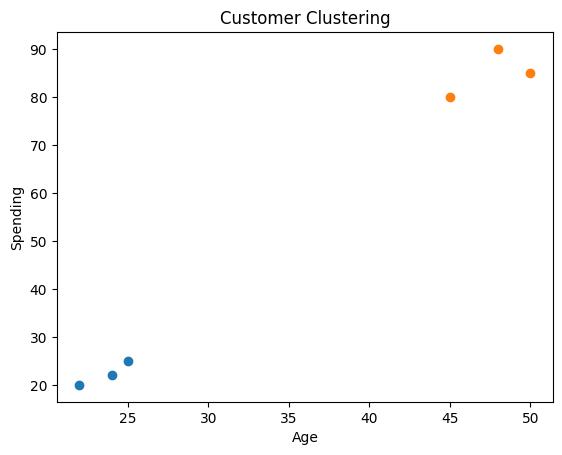

In [6]:
import matplotlib.pyplot as plt

plt.scatter(
    [22, 25, 24],
    [20, 25, 22]
)

plt.scatter(
    [45, 50, 48],
    [80, 85, 90]
)

plt.xlabel("Age")
plt.ylabel("Spending")
plt.title("Customer Clustering")

plt.show()

How do we decide K?

This is one of the most important K-Means questions.

Suppose we don't know whether there are:

2 groups?
3 groups?
4 groups?
5 groups?

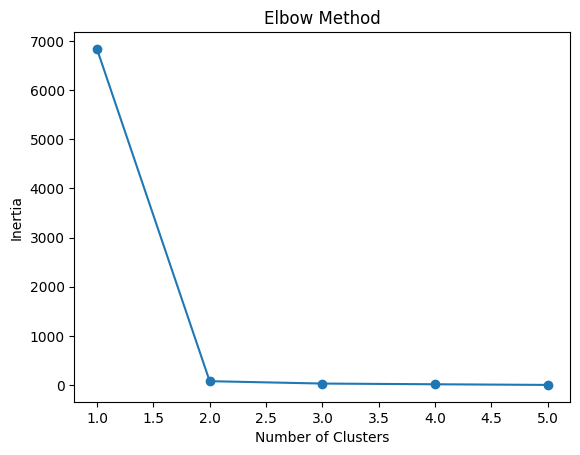

Silhouette Score: 0.9132372992932974


In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X = [
    [22, 20],
    [25, 25],
    [24, 22],
    [45, 80],
    [50, 85],
    [48, 90]
]

inertia = []

for k in range(1, 6):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X)

    inertia.append(model.inertia_)

plt.plot(range(1, 6), inertia, marker="o")

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

#Another K-Means metric: Silhouette Score

'''Closer to +1 → Good separation
Around 0     → Overlapping clusters
Negative     → Poor clustering'''

from sklearn.metrics import silhouette_score

score = silhouette_score(X, labels)

print("Silhouette Score:", score)

Important K-Means limitation

K-Means uses distance.

Therefore, feature scales matter.

Suppose:

Age → 20–60

Salary → 20,000–200,000

Salary has much larger numbers.

It can dominate the distance calculation.

So we often use StandardScaler.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Then:

model.fit(X_scaled)

For K-Means, remember:

Scaling is usually important.